# Reto Spaceship Titanic - Avance 1

| | |
|---|---|
| **Equipo** | Israel González Huerta A01751433<br>Luis David Pozos Tamez A01800657<br>Adrián Proaño Bernal A01752615<br>Juan Pablo Solís Gómez A01800430<br>Karol Alexis Alvarado Davila A01751711 |
| **Fecha** | 31 de agosto de 2026 |

---

## 1. Carga y comprensión del dataset

### 1.1 Carga de `train.csv` y `test.csv`

Carga de los conjuntos de entrenamiento y prueba provistos por Kaggle. No se realiza split adicional: todo el trabajo de preparación se desarrolla sobre `train.csv`.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

import math

In [36]:
train = pd.read_csv('../data/titanic_data/train.csv')
test = pd.read_csv('../data/titanic_data/test.csv')

### 1.2 Inspección de estructura: shape, tipos de variables y primeras filas

Revisión del número de filas y columnas, tipos de datos (`dtypes`) por variable, y muestra de las primeras observaciones (`head`) para comprender el formato general del dataset.

In [37]:
print(test.shape)
print(train.shape)

(4277, 13)
(8693, 14)


In [38]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [39]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [40]:
train.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

### 1.3 Identificación de la variable target y tipo de problema

`Transported` es nuestra variable objetivo. El problema que se está intentando resolver en este escenario es identificar a los pasajeros que fueron transportados a la dimensión alterna, por lo que cuadra perfectamente con el dato booleano que aparece en el training set. 

El tipo de problema al que nos enfrentamos es una **clasificación binaria supervisada**, ya que la predicción solo puede caer en dos categorías, y además tenemos acceso a una muestra con valores predefinidos de True/False para `Transported` (test.csv). A partir de esto podemos verificar algunas de las respuestas que da el modelo y proporcionarle retroalimentación.

## 2. Análisis exploratorio (EDA)

### 2.1 Valores faltantes: porcentaje por columna y clasificación (informativo vs. real)

Cálculo del porcentaje de faltantes por columna. Cada variable se clasifica como **faltante informativo** o **faltante real**, justificando cada clasificación con el contexto del dataset descrito en Kaggle.

In [41]:
faltantes = train.isnull().sum()
faltantes / len(train) * 100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

**Check extra:** confirmar la hipótesis acerca del CryoSleep. Los pasajeros no deberían de gastar si están en este estado

In [42]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
total_spend = train[spend_cols].sum(axis=1, skipna=True)
check = train.loc[train["CryoSleep"].notna() & (total_spend > 0), "CryoSleep"]
print((check == True).sum(), "de", len(check))
print(check.value_counts(dropna=False))

0 de 4921
CryoSleep
False    4921
Name: count, dtype: int64


**Tabla de clasificación de variables**

| Variable | Faltante | Justificación |
|---|---|---|
| CryoSleep | Faltante real  | Un pasajero dormido no puede consumir. Si el gasto es > 0, CryoSleep debe ser false. Entonces los casos faltantes, son un hueco. |
| ShoppingMall |Faltante informativo  | Siguiendo con el razonamiento anterior, si CyroSleep es true, ShoppingMall debe ser 0. Entonces el pasajero no gastó nada. Si CryoSleep es False o desconocido, es un faltante real que requiere imputación estadística (mediana condicionada a pasajeros despiertos).  |
| VIP | Faltante real  | No hay motivo lógico por el que la ausencia signifique algo sistinto a "no se capturó". |
| HomePlanet | Faltante real | Su ausencia es porque no se capturó. Puede ser posible recuperarla por relaciones de miembros del mosmo grupo, deck o cabin |
| Name | Faltante real | No es relevante. Su ausencia no aporta nada al target, además es un identificador casi único. |
| Cabin | Faltante real | Si falta, no afecta al target, puede ser una falta de captura y no necesariamente que el pasajero no tenga cabina. |
| VRDeck | Faltante informativo | Igual que ShoppingMall, si CryoSleep es true, tiene que ser 0. Se tendría que comprobar que el pasajero está o estuvo activo para imputar el faltante. |
| Spa | Faltante informativo | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| FoodCourt | Faltante informativo  | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| Destination | Faltante real | La ausencia es porque no se capturó, sin embargo el destino no aporta nada al target porque los pasajeros no son acomodados necesariamente por destino. |
| RoomService | Faltante informativo | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| Age | Faltante real | Al igual que el nombre, no hay razón por la que "sin edad" signifique algo. No tiene relación determinística con otras variables. |

### 2.2 Variables numéricas: distribución, skewness y outliers

Histogramas de las variables numéricas, cálculo de asimetría (skewness) y detección de outliers mediante el método de Tukey/rango intercuartílico (IQR).

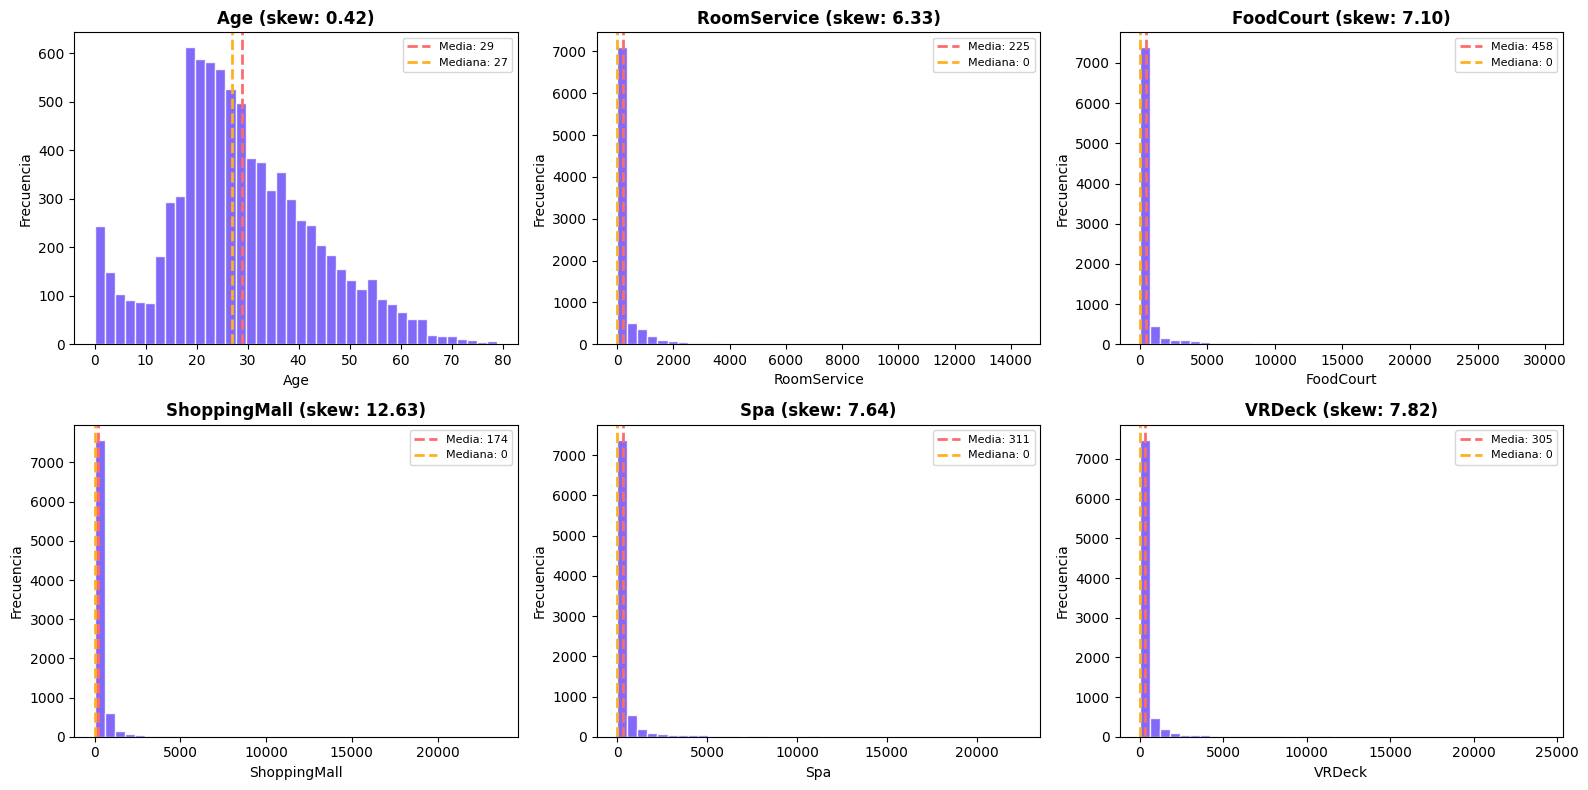

In [43]:
cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, cols):
    ax.hist(train[col].dropna(), bins=40, color='#6C4FF6', edgecolor='white', alpha=0.85)
    ax.axvline(train[col].mean(), color='#FF6B6B', linewidth=2,
               linestyle='--', label=f"Media: {train[col].mean():,.0f}")
    ax.axvline(train[col].median(), color='#FFB020', linewidth=2,
               linestyle='--', label=f"Mediana: {train[col].median():,.0f}")

    ax.set_title(f"{col} (skew: {train[col].skew():.2f})", fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [44]:
info_outliers = []

for col in cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lim_inf) | (train[col] > lim_sup)]

    info_outliers.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite inferior': lim_inf,
        'Límite superior': lim_sup,
        'Num outliers': len(outliers),
        'Porcentaje outliers': len(outliers) / len(train) * 100
    })

outliers_df = pd.DataFrame(info_outliers)

outliers_df

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Num outliers,Porcentaje outliers
0,Age,19.0,38.0,19.0,-9.5,66.5,77,0.885770
1,RoomService,0.0,47.0,47.0,-70.5,117.5,1861,21.408029
2,FoodCourt,0.0,76.0,76.0,-114.0,190.0,1823,20.970896
3,ShoppingMall,0.0,27.0,27.0,-40.5,67.5,1829,21.039917
4,Spa,0.0,59.0,59.0,-88.5,147.5,1788,20.568273
5,VRDeck,0.0,46.0,46.0,-69.0,115.0,1809,20.809847


### 2.3 Variables categóricas: cardinalidad, distribución y desbalance

Análisis de la cardinalidad de cada variable categórica, distribución de sus categorías y detección de variables con desbalance extremo entre clases.

In [45]:
v_categoricas = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin']

""" for col in v_categoricas:
    print(f"Valores en {col}:")
    print(train[col].value_counts())
 """

cardinalidad = train[v_categoricas].nunique().sort_values(ascending=False)
cardinalidad

Cabin          6560
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
dtype: int64

Cabin tiene una cardinalidad demasiado alta, pero es una variable compuesta. Podemos separar Deck, Side y NumCabin para analizar si alguna de estas variables tiene una cardinalidad más baja y que pueda ser de verdadera utilidad para el modelo.

In [46]:
train[['Deck', 'NumCabin', 'Side']] = train['Cabin'].str.split('/', expand=True)
train['NumCabin'] = pd.to_numeric(train['NumCabin'])

test[['Deck', 'NumCabin', 'Side']] = test['Cabin'].str.split('/', expand=True)
test['NumCabin'] = pd.to_numeric(test['NumCabin'])

Comprobamos la cardinalidad otra vez con las nuevas columnas:

In [47]:
v_categoricas = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'NumCabin', 'Deck', 'Side']

cardinalidad = train[v_categoricas].nunique().sort_values(ascending=False)
cardinalidad

NumCabin       1817
Deck              8
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
Side              2
dtype: int64

### 2.4 Relación de cada variable con el target

Crosstabs entre variables categóricas y `Transported`, y boxplots de variables numéricas segmentados por `Transported`. Este análisis es la base para justificar qué variables entran y cuáles se descartan en la siguiente etapa. Se excluye NumCabin por cardinalidad

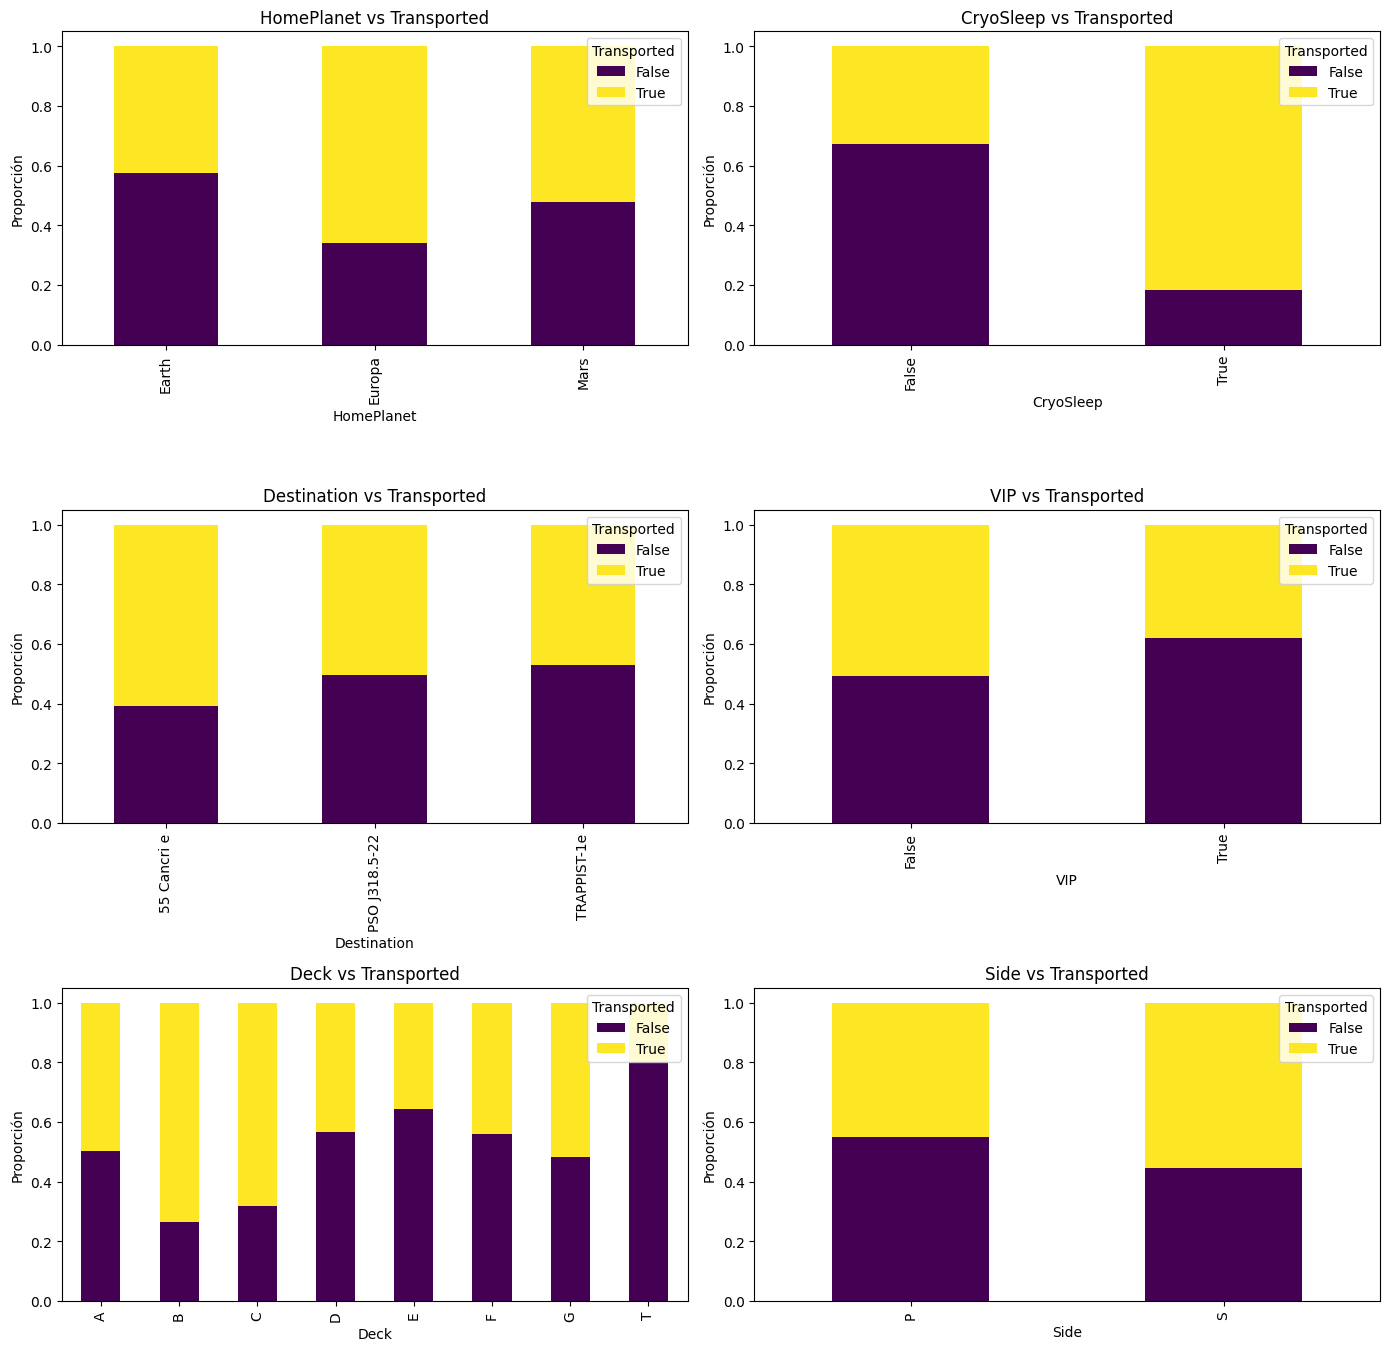

In [48]:
v_categoricas_crosstabs = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(v_categoricas_crosstabs):
    ct = pd.crosstab(train[col], train['Transported'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(f'{col} vs Transported')
    axes[i].set_ylabel('Proporción')
    axes[i].legend(title='Transported', loc='upper right')

for j in range(len(v_categoricas_crosstabs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

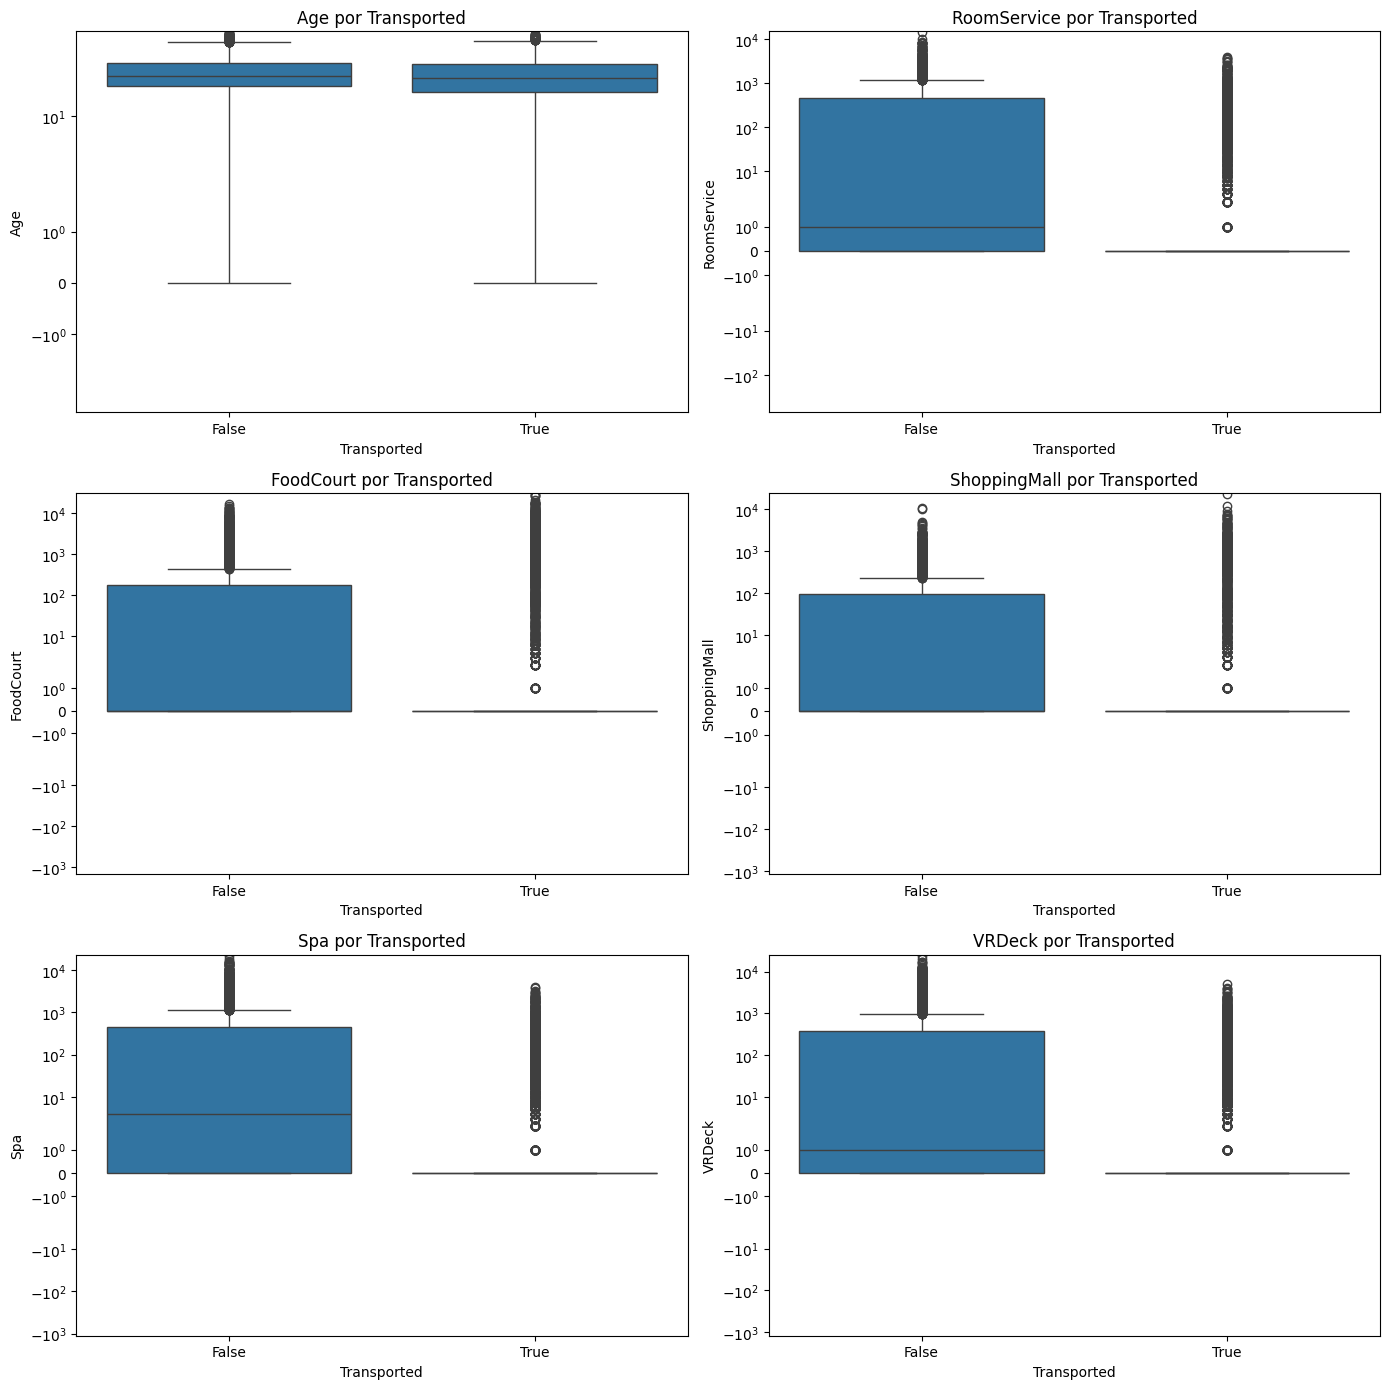

In [49]:
v_numericas = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(v_numericas):
    sns.boxplot(data=train, x='Transported', y=col, ax=axes[i])
    axes[i].set_title(f'{col} por Transported')
    axes[i].set_yscale('symlog')

plt.tight_layout()
plt.show()

## 3. Selección y descarte de variables

### 3.1 Variables incluidas en el pipeline

Listado de variables que se conservan para el modelado, con la evidencia del EDA que respalda cada inclusión (relación con el target, faltantes manejables, cardinalidad razonable, etc.).

In [50]:
v_conservar = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'Deck',
    'Side',
    'NumCabin',   
]

v_descartar = [
    'PassengerId', 
    'Name', 
    'Age', 
    'VIP',
    'Cabin'
]

v_binarizar = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
]

Las seis variables que se conservan son las que muestran una separación visible en los crosstabs de la sección 2.4 y que además tienen una cardinalidad que el modelo puede manejar.

**CryoSleep** es la variable con la relación más fuerte con el target. En su crosstab la barra se parte casi en dos bloques distintos: la proporción de transportados entre los pasajeros dormidos está muy por encima de la de los pasajeros despiertos. Además solo tiene 2 categorías y 2.50% de faltantes, que son recuperables con la regla del gasto que ya validamos en la sección 2.1.

**HomePlanet** separa bien a los tres planetas. Europa queda arriba de la media, Earth abajo y Mars en medio, y la diferencia entre los extremos es grande. Con 3 categorías y 2.31% de faltantes, es de las variables más baratas de incluir.

**Destination** en la sección 2.1 la habíamos anotado como poco relevante, pero el crosstab muestra que 55 Cancri e tiene una proporción de transportados claramente mayor que TRAPPIST-1e. La diferencia es menor que la de CryoSleep, pero es consistente, y con 3 categorías y 2.09% de faltantes el costo de conservarla es mínimo. Se corrige entonces la anotación previa y la variable entra al pipeline.

**Deck** tiene 8 categorías y es la que más se benefició de haber descompuesto Cabin. Las cubiertas B y C están claramente arriba y E y F abajo, así que la variable aporta señal propia. La cubierta T casi no tiene pasajeros, pero eso no invalida al resto de las categorías.

**Side** solo tiene 2 categorías y la diferencia entre estribor y babor es pequeña, pero es limpia y constante. Con cardinalidad 2, incluirla cuesta una sola columna.

**NumCabin** tiene 1817 valores distintos, así que no se puede usar tal cual. Se conserva porque el número de cabina ordena físicamente las cabinas dentro de cada deck, y pasajeros con números cercanos viajaron juntos en la misma zona de la nave. Esperamos que esa vecindad conserve señal una vez agrupada en rangos, que es lo que se hace en la sección 5.2.

### 3.2 Variables descartadas

Listado de variables excluidas del pipeline, justificando cada descarte con evidencia concreta: porcentaje de faltantes, desbalance extremo, ausencia de relación con el target, cardinalidad excesiva o redundancia con otra variable.

**PassengerId** es un identificador y tiene tantos valores distintos como filas. La primera parte del id corresponde al grupo con el que viajó el pasajero y en principio podría explotarse, pero como columna directa no aporta nada y no se puede codificar. Se descarta.

**Name** tiene 2.30% de faltantes y es prácticamente único por pasajero, así que es la variable de mayor cardinalidad del dataset. No guarda relación con el target y cualquier codificación produciría miles de columnas vacías.

**Age** está limpia: solo 0.89% de outliers, muy por debajo del 20% de las variables de gasto, y 2.06% de faltantes. El problema es que no separa. En los boxplots de la sección 2.4 las cajas de Transported true y false quedan prácticamente encimadas, con la misma mediana, el mismo rango intercuartílico y bigotes casi idénticos. Es una variable limpia pero sin señal, así que se descarta.

**VIP** tiene desbalance extremo: menos del 3% de los pasajeros son VIP. Sobre una base tan chica, cualquier diferencia en la proporción de transportados es poco confiable, y en el crosstab la separación tampoco es grande. Sumando 2.34% de faltantes, no se justifica imputarla para conservar una columna casi constante.

**Cabin** se descarta como columna original porque ya quedó descompuesta en Deck, NumCabin y Side. Con 6560 valores distintos es inutilizable tal cual, y mantenerla junto a sus tres componentes sería pura redundancia.

In [51]:
# Por ahora, conservamos Passenger ID que puede ser útil para el match con el testing set, pero se descarta en el modelo final.
v_descartar = [
    'Name', 
    'Age', 
    'VIP',
    'Cabin'
]

train = train.drop(columns=v_descartar)

### 3.3 Evaluación de binarización para variables con desbalance extremo

Antes de descartar variables con clases muy desbalanceadas (por ejemplo, servicios de gasto a bordo), se evalúa si transformarlas en indicadores binarios (`HasPool`, `HasCabin`, etc.) preserva señal útil para el target.

Las cinco variables de gasto tienen más de 20% de outliers por IQR y un sesgo muy alto, pero eso no significa que no sirvan. Lo que probablemente separa a los pasajeros no es cuánto gastaron sino si gastaron algo, porque el gasto en cero es justamente la huella que deja CryoSleep. Antes de decidir si se descartan, comparamos la proporción de transportados entre los pasajeros que gastaron cero y los que gastaron más de cero en cada servicio.

In [52]:
resumen_bin = []

for col in v_binarizar:
    ind = train[col].fillna(0) > 0

    resumen_bin.append({
        'Variable': col,
        'Pasajeros con gasto': ind.sum(),
        'Transportados sin gasto': train.loc[~ind, 'Transported'].mean(),
        'Transportados con gasto': train.loc[ind, 'Transported'].mean()
    })

resumen_bin = pd.DataFrame(resumen_bin)

resumen_bin

,Variable,Pasajeros con gasto,Transportados sin gasto,Transportados con gasto
0,RoomService,2935,0.627822,0.259966
1,FoodCourt,3054,0.589289,0.345449
2,ShoppingMall,2898,0.596894,0.317115
3,Spa,3186,0.634465,0.277464
4,VRDeck,3010,0.624494,0.275415


La binarización sí conserva señal, y en varios servicios la separación es más fuerte que la de muchas variables categóricas. En RoomService, Spa y VRDeck los pasajeros que gastaron algo se transportan bastante menos que los que no gastaron nada, mientras que en FoodCourt y ShoppingMall la diferencia va en el otro sentido o es más suave. El corte en cero recupera casi toda la separación sin arrastrar el sesgo ni los outliers, así que cada variable de gasto se convierte en un indicador binario (UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa y UsoVRDeck).

## 4. Manejo de faltantes

### 4.1 Imputación de faltantes informativos

Estrategia de imputación aplicada a las variables cuyo faltante fue clasificado como informativo en el paso 2.1 (por ejemplo, imputación condicionada al valor de otra variable relacionada), con su justificación.

| Variable | % Faltantes | Estrategia de imputación | Justificación |
|---|---|---|---|
| RoomService | 2.08% | 1) Si `CryoSleep == True` → imputar 0. 2) Si `CryoSleep == False` → imputar con la mediana de la columna calculada solo sobre pasajeros despiertos (`CryoSleep == False`). 3) Si `CryoSleep` también es faltante, se asume "despierto" (criterio conservador) y se aplica el paso 2. | El check de 2.1 confirmó que 0 de 4921 pasajeros en CryoSleep gastaron algo: el 0 es determinístico, no una estimación. La mediana condicionada evita contaminar la imputación con el pico de ceros que aportan los pasajeros dormidos. |
| FoodCourt | 2.11% | Misma regla que RoomService (pasos 1-3). |  |
| ShoppingMall | 2.39% | Misma regla que RoomService (pasos 1-3). |  |
| Spa | 2.11% | Misma regla que RoomService (pasos 1-3). |  |
| VRDeck | 2.16% | Misma regla que RoomService (pasos 1-3). |  |

### 4.2 Imputación de faltantes reales

Estrategia de imputación aplicada a las variables con faltantes reales (por ejemplo, medidas de tendencia central para numéricas o moda/categoría "Unknown" para categóricas), con su justificación.

| Variable | % Faltantes | Estrategia de imputación | Justificación |
|---|---|---|---|
| CryoSleep | 2.50% | 1) Si el gasto total (`RoomService+FoodCourt+ShoppingMall+Spa+VRDeck`) > 0 → `False` (regla determinística). 2) Si el gasto total es 0 o también falta → imputar con la moda global de `CryoSleep`. | El check de 2.1 valida el paso 1 en sentido inverso (gasto > 0 excluye CryoSleep=True). El paso 2 es un faltante genuino sin otra señal disponible una vez agotada la regla de gasto. |
| HomePlanet | 2.31% | 1) Imputar con la moda de `HomePlanet` condicionada al `Deck`. 2) Si el `Deck` también falta, usar la moda global. | El crosstab de 2.4 muestra que ciertos decks están asociados casi exclusivamente a un `HomePlanet`. No se usa `PassengerId` porque esa columna se descarta en la sección 3. |
| Destination | 2.09% | Imputar con la moda global (`TRAPPIST-1e`). | En 2.1 se concluyó que Destination no aporta señal relevante al target, por lo que no se justifica una imputación condicionada más compleja. |
| Deck | 2.29% (heredado de `Cabin`) | 1) Imputar con la moda de `Deck` condicionada a `HomePlanet` (ya imputado). 2) Si no hay dato, usar la moda global de `Deck`. | `Deck` está correlacionado con `HomePlanet` (evidencia de los crosstabs en 2.4). No se usa `PassengerId` porque esa columna se descarta en la sección 3. |
| Side | 2.29% (heredado de `Cabin`) | Imputar con la moda global de `Side`. | `Side` no mostró relación fuerte con el target en 2.4, por lo que basta la moda global. No se usa `PassengerId` porque esa columna se descarta en la sección 3. |
| NumCabin | 2.29% (heredado de `Cabin`) | Imputar con la mediana de `NumCabin` dentro del mismo `Deck` (ya imputado); si el `Deck` también es faltante, usar la mediana global. | Es una variable de alta cardinalidad pero con estructura por rangos dentro de cada deck; la mediana condicionada preserva mejor la posición relativa que una mediana global. |

### 4.3 Resumen de estrategia de imputación por variable

Tabla o resumen que consolida, por variable, el tipo de faltante y la estrategia de imputación elegida, evitando aplicar un único criterio genérico sin argumento.

| Variable | Tipo de faltante | Estrategia de imputación (resumen) | Justificación |
|---|---|---|---|
| CryoSleep | Real | Regla por gasto total (>0 → False); si no, moda global | Confirmada por el check de 2.1; sin otra señal disponible para el resto |
| HomePlanet | Real | Moda por `Deck` → moda global | Los decks comparten planeta de origen (2.4); no depende de `PassengerId` (se descarta en 3.2) |
| Destination | Real | Moda global (`TRAPPIST-1e`) | Sin relación con el target (2.1); no amerita imputación condicionada |
| Deck | Real (heredado de `Cabin`) | Moda por `HomePlanet` → moda global | Correlación con `HomePlanet` (2.4); no depende de `PassengerId` |
| Side | Real (heredado de `Cabin`) | Moda global | Sin relación fuerte con el target (2.4); no depende de `PassengerId` |
| NumCabin | Real (heredado de `Cabin`) | Mediana condicionada al `Deck` → mediana global | Alta cardinalidad con estructura por rangos dentro de cada deck |
| RoomService | Informativo | `CryoSleep`=True → 0; si no, mediana de despiertos | 0 de 4921 dormidos gastaron algo (check de 2.1) |
| FoodCourt | Informativo | Misma regla que RoomService | Misma dependencia estructural con `CryoSleep` |
| ShoppingMall | Informativo | Misma regla que RoomService |  |
| Spa | Informativo | Misma regla que RoomService |  |
| VRDeck | Informativo | Misma regla que RoomService |  |

In [53]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

gasto_total_original = train[spend_cols].sum(axis=1, skipna=True)

dormido = train["CryoSleep"] == True
despierto_o_faltante = train["CryoSleep"].fillna(False) == False

for col in spend_cols:
    mediana_despiertos = train.loc[despierto_o_faltante & train[col].notna(), col].median()
    falta = train[col].isna()
    train.loc[falta & dormido, col] = 0
    train.loc[falta & despierto_o_faltante, col] = mediana_despiertos

falta_cryo = train["CryoSleep"].isna()
train.loc[falta_cryo & (gasto_total_original > 0), "CryoSleep"] = False
train["CryoSleep"] = train["CryoSleep"].fillna(train["CryoSleep"].mode()[0])

def moda_por_grupo(serie):
    return serie.mode().iloc[0] if serie.notna().any() else np.nan

train["HomePlanet"] = train["HomePlanet"].fillna(
    train.groupby("Deck")["HomePlanet"].transform(moda_por_grupo)
)
train["HomePlanet"] = train["HomePlanet"].fillna(train["HomePlanet"].mode()[0])

train["Destination"] = train["Destination"].fillna(train["Destination"].mode()[0])

train["Deck"] = train["Deck"].fillna(
    train.groupby("HomePlanet")["Deck"].transform(moda_por_grupo)
)
train["Deck"] = train["Deck"].fillna(train["Deck"].mode()[0])

train["Side"] = train["Side"].fillna(train["Side"].mode()[0])

train["NumCabin"] = train["NumCabin"].fillna(
    train.groupby("Deck")["NumCabin"].transform("median")
)
train["NumCabin"] = train["NumCabin"].fillna(train["NumCabin"].median())

train.isnull().sum()

C:\Users\karal\AppData\Local\Temp\ipykernel_14700\3339307717.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  despierto_o_faltante = train["CryoSleep"].fillna(False) == False
C:\Users\karal\AppData\Local\Temp\ipykernel_14700\3339307717.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train["CryoSleep"] = train["CryoSleep"].fillna(train["CryoSleep"].mode()[0])


PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
NumCabin        0
Side            0
dtype: int64

## 5. Codificación de variables categóricas

### 5.1 Codificación de variables nominales

Aplicación de codificación a variables categóricas sin orden natural, justificando la elección según cardinalidad y naturaleza de cada variable.

In [54]:
train = pd.get_dummies(train, columns=['HomePlanet', 'Destination', 'Deck'], drop_first=True)
train['Side'] = train['Side'].map({'P': 0, 'S': 1})
train['CryoSleep'] = train['CryoSleep'].astype(int)

train

,PassengerId,CryoSleep,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,NumCabin,Side,...,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
0,0001_01,0,0.0,0.0,0.0,0.0,0.0,False,0.0,0,...,False,False,True,True,False,False,False,False,False,False
1,0002_01,0,109.0,9.0,25.0,549.0,44.0,True,0.0,1,...,False,False,True,False,False,False,False,True,False,False
2,0003_01,0,43.0,3576.0,0.0,6715.0,49.0,False,0.0,1,...,False,False,True,False,False,False,False,False,False,False
3,0003_02,0,0.0,1283.0,371.0,3329.0,193.0,False,0.0,1,...,False,False,True,False,False,False,False,False,False,False
4,0004_01,0,303.0,70.0,151.0,565.0,2.0,True,1.0,1,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,0.0,6819.0,0.0,1643.0,74.0,False,98.0,0,...,False,False,False,False,False,False,False,False,False,False
8689,9278_01,1,0.0,0.0,0.0,0.0,0.0,False,1499.0,1,...,False,True,False,False,False,False,False,False,True,False
8690,9279_01,0,0.0,0.0,1872.0,1.0,0.0,True,1500.0,1,...,False,False,True,False,False,False,False,False,True,False
8691,9280_01,0,0.0,1049.0,0.0,353.0,3235.0,False,608.0,1,...,False,False,False,False,False,False,True,False,False,False


### 5.2 Codificación de variables ordinales

Evaluación de si alguna variable categórica presenta orden natural y, de ser así, aplicación de una codificación ordinal justificada.

In [55]:
bins = [0, 300, 600, 900, 1200, 1500, 1800, train['NumCabin'].max()+1]
train['NumCabin_bin'] = pd.cut(train['NumCabin'], bins=bins, labels=False, include_lowest=True)
train

,PassengerId,CryoSleep,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,NumCabin,Side,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,NumCabin_bin
0,0001_01,0,0.0,0.0,0.0,0.0,0.0,False,0.0,0,...,False,True,True,False,False,False,False,False,False,0
1,0002_01,0,109.0,9.0,25.0,549.0,44.0,True,0.0,1,...,False,True,False,False,False,False,True,False,False,0
2,0003_01,0,43.0,3576.0,0.0,6715.0,49.0,False,0.0,1,...,False,True,False,False,False,False,False,False,False,0
3,0003_02,0,0.0,1283.0,371.0,3329.0,193.0,False,0.0,1,...,False,True,False,False,False,False,False,False,False,0
4,0004_01,0,303.0,70.0,151.0,565.0,2.0,True,1.0,1,...,False,True,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,0.0,6819.0,0.0,1643.0,74.0,False,98.0,0,...,False,False,False,False,False,False,False,False,False,0
8689,9278_01,1,0.0,0.0,0.0,0.0,0.0,False,1499.0,1,...,True,False,False,False,False,False,False,True,False,4
8690,9279_01,0,0.0,0.0,1872.0,1.0,0.0,True,1500.0,1,...,False,True,False,False,False,False,False,True,False,4
8691,9280_01,0,0.0,1049.0,0.0,353.0,3235.0,False,608.0,1,...,False,False,False,False,False,True,False,False,False,2


### 5.3 Verificación de ausencia de columnas tipo `object`

Comprobación de que, tras la codificación, ninguna columna del dataset conserva el tipo `object`.

In [56]:
cols_object = train.drop(columns=['PassengerId']).select_dtypes(include='object').columns.tolist()
assert len(cols_object) == 0, f"Aún quedan columnas tipo object: {cols_object}"
train

,PassengerId,CryoSleep,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,NumCabin,Side,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,NumCabin_bin
0,0001_01,0,0.0,0.0,0.0,0.0,0.0,False,0.0,0,...,False,True,True,False,False,False,False,False,False,0
1,0002_01,0,109.0,9.0,25.0,549.0,44.0,True,0.0,1,...,False,True,False,False,False,False,True,False,False,0
2,0003_01,0,43.0,3576.0,0.0,6715.0,49.0,False,0.0,1,...,False,True,False,False,False,False,False,False,False,0
3,0003_02,0,0.0,1283.0,371.0,3329.0,193.0,False,0.0,1,...,False,True,False,False,False,False,False,False,False,0
4,0004_01,0,303.0,70.0,151.0,565.0,2.0,True,1.0,1,...,False,True,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,0.0,6819.0,0.0,1643.0,74.0,False,98.0,0,...,False,False,False,False,False,False,False,False,False,0
8689,9278_01,1,0.0,0.0,0.0,0.0,0.0,False,1499.0,1,...,True,False,False,False,False,False,False,True,False,4
8690,9279_01,0,0.0,0.0,1872.0,1.0,0.0,True,1500.0,1,...,False,True,False,False,False,False,False,True,False,4
8691,9280_01,0,0.0,1049.0,0.0,353.0,3235.0,False,608.0,1,...,False,False,False,False,False,True,False,False,False,2


## 6. Transformación de variables numéricas

### 6.1 Evaluación del sesgo (skewness)

Revisión del coeficiente de asimetría de cada variable numérica para identificar cuáles presentan sesgo significativo.

In [58]:
v_continuas = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'NumCabin']

resumen_sesgo = pd.DataFrame({
    'Skewness': train[v_continuas].skew(),
    'Media': train[v_continuas].mean(),
    'Mediana': train[v_continuas].median(),
    'Maximo': train[v_continuas].max(),
    '% ceros': (train[v_continuas] == 0).mean() * 100
})

resumen_sesgo['Sesgo relevante'] = resumen_sesgo['Skewness'].abs() > 1

resumen_sesgo

,Skewness,Media,Mediana,Maximo,% ceros,Sesgo relevante
RoomService,6.397911,220.035316,0.0,14327.0,64.937306,True
FoodCourt,7.177621,448.486023,0.0,29813.0,63.568388,True
ShoppingMall,12.764016,169.585183,0.0,23492.0,65.374439,True
Spa,7.716697,304.670309,0.0,22408.0,61.992408,True
VRDeck,7.904685,298.305303,0.0,24133.0,63.924997,True
NumCabin,0.714676,600.452836,435.0,1894.0,0.207063,False


Solo se evalúan las variables continuas que quedaron vivas después de la sección 5. CryoSleep, Side y las dummies de HomePlanet, Destination y Deck son binarias: su asimetría refleja el desbalance de clases, no un sesgo corregible con una transformación, y aplicarles una sería tratarlas como magnitudes cuando solo son indicadores. NumCabin_bin tampoco entra porque es una codificación ordinal ya acotada a siete niveles, y PassengerId es identificador.

El criterio para marcar sesgo relevante es un valor absoluto de skewness mayor a 1, el umbral convencional para asimetría fuerte. Las cinco variables de gasto lo superan por mucho, en línea con lo que ya se veía en los histogramas de la sección 2.2 y con el 20 por ciento o más de outliers por IQR de esa misma sección: son distribuciones de cola larga con una masa de ceros enorme, formada por los pasajeros en CryoSleep más los que simplemente no consumieron ese servicio. NumCabin en cambio se reparte de forma casi uniforme a lo largo de la nave y su asimetría es despreciable, así que no requiere transformación.

### 6.2 Aplicación de transformaciones justificadas

Aplicación de una transformación (p. ej. logarítmica o `PowerTransformer`) a las variables con sesgo relevante, justificando la elección según el tipo y grado de sesgo detectado.

Las cinco variables marcadas son no negativas y concentran la mayor parte de su masa en cero, así que las dos opciones razonables son log1p, el logaritmo desplazado que sí está definido en cero, y PowerTransformer con Yeo-Johnson. Se descarta el logaritmo simple porque no está definido en cero y aquí el cero es el valor más frecuente. Antes de decidir, se comparan ambas opciones sobre el sesgo resultante.

In [59]:
from sklearn.preprocessing import PowerTransformer

v_transformar = resumen_sesgo.index[resumen_sesgo['Sesgo relevante']].tolist()

skew_log1p = np.log1p(train[v_transformar]).skew()

yeo = PowerTransformer(method='yeo-johnson', standardize=False)
skew_yeo = pd.DataFrame(
    yeo.fit_transform(train[v_transformar]),
    columns=v_transformar,
    index=train.index
).skew()

comparacion_metodos = pd.DataFrame({
    'Skew original': train[v_transformar].skew(),
    'Skew log1p': skew_log1p,
    'Skew Yeo-Johnson': skew_yeo
})

comparacion_metodos

,Skew original,Skew log1p,Skew Yeo-Johnson
RoomService,6.397911,1.145302,0.814632
FoodCourt,7.177621,1.134644,0.762426
ShoppingMall,12.764016,1.236962,0.854877
Spa,7.716697,1.107901,0.710442
VRDeck,7.904685,1.185524,0.783650


Ambos métodos reducen el sesgo en más de un orden de magnitud y la diferencia entre ellos es pequeña frente a esa corrección. Se elige log1p por tres razones.

La primera es que preserva el cero, porque log1p de cero es cero, así que la masa de ceros sigue siendo un valor único y distinguible. Eso importa aquí más que en un caso genérico: en la sección 3.3 comprobamos que la señal fuerte de estas variables no es cuánto se gastó sino si se gastó algo, y esa frontera es justamente el cero. Yeo-Johnson desplaza el cero a un valor arbitrario y diluye ese corte.

La segunda es que no arrastra parámetros al test. log1p es una función fija, mientras que Yeo-Johnson estima una lambda por variable sobre train que habría que guardar y reaplicar sobre test para no filtrar información. Con una ganancia marginal, no se justifica ese costo.

La tercera es que es interpretable y reversible. Un coeficiente sobre el logaritmo del gasto en Spa se lee como el efecto de un cambio relativo en ese gasto, mientras que sobre una potencia con lambda estimada no se lee.

El sesgo residual que queda después de transformar no es ruido mal corregido: viene de la bimodalidad, es decir de la masa en cero frente a la nube de gasto positivo, y ninguna transformación monótona puede eliminarla porque no es un problema de escala sino de dos poblaciones distintas.

NumCabin se deja sin transformar por lo dicho en 6.1.

In [60]:
train_sin_transformar = train[v_transformar].copy()

train[v_transformar] = np.log1p(train[v_transformar])

resumen_transformacion = pd.DataFrame({
    'Skew original': train_sin_transformar.skew(),
    'Skew transformado': train[v_transformar].skew(),
    'Maximo original': train_sin_transformar.max(),
    'Maximo transformado': train[v_transformar].max(),
    '% ceros (se conserva)': (train[v_transformar] == 0).mean() * 100
})

resumen_transformacion

,Skew original,Skew transformado,Maximo original,Maximo transformado,% ceros (se conserva)
RoomService,6.397911,1.145302,14327.0,9.569971,64.937306
FoodCourt,7.177621,1.134644,29813.0,10.302733,63.568388
ShoppingMall,12.764016,1.236962,23492.0,10.064458,65.374439
Spa,7.716697,1.107901,22408.0,10.017218,61.992408
VRDeck,7.904685,1.185524,24133.0,10.091377,63.924997


### 6.3 Comparación de distribuciones antes y después

Visualización comparativa (histogramas) de cada variable transformada, mostrando su distribución original frente a la distribución tras la transformación.

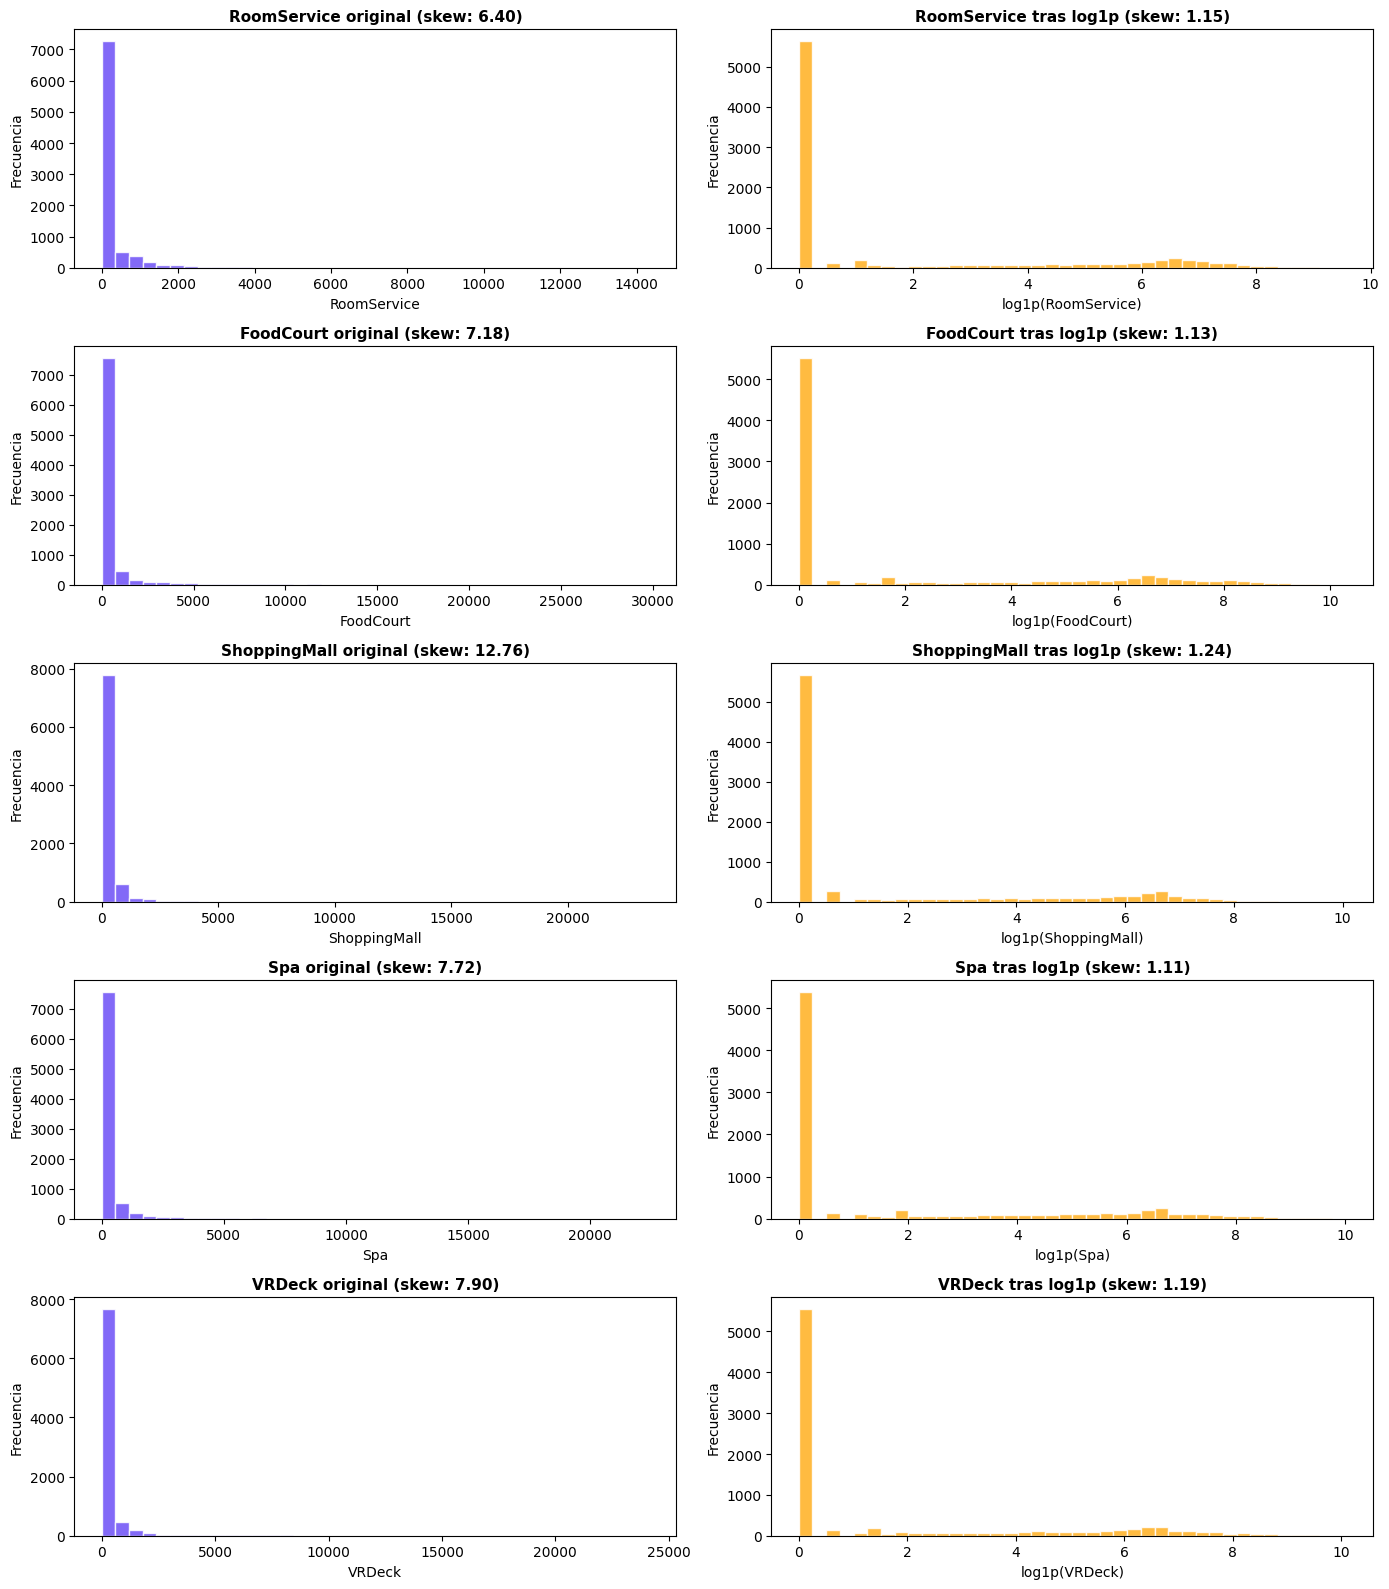

In [61]:
fig, axes = plt.subplots(nrows=len(v_transformar), ncols=2,
                         figsize=(14, 3.2 * len(v_transformar)))

for i, col in enumerate(v_transformar):
    axes[i, 0].hist(train_sin_transformar[col], bins=40,
                    color='#6C4FF6', edgecolor='white', alpha=0.85)
    axes[i, 0].set_title(f"{col} original (skew: {train_sin_transformar[col].skew():.2f})",
                         fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')

    axes[i, 1].hist(train[col], bins=40,
                    color='#FFB020', edgecolor='white', alpha=0.85)
    axes[i, 1].set_title(f"{col} tras log1p (skew: {train[col].skew():.2f})",
                         fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel(f"log1p({col})")
    axes[i, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

En la columna izquierda las cinco variables se ven prácticamente como una sola barra pegada al origen: la cola llega a decenas de miles de créditos pero contiene tan pocos pasajeros que el histograma no la resuelve. Después de aplicar log1p la cola se comprime y el gasto positivo se despliega en una campana ancha, lo que vuelve visible la estructura que antes quedaba aplastada.

Lo que no desaparece es la barra en cero, y eso es lo esperado y lo deseable: sigue separando a los pasajeros que no consumieron, ya sea porque estaban dormidos o simplemente porque no gastaron, del resto. El resultado es una distribución bimodal en lugar de una exponencial, que es una forma mucho más manejable para cualquier modelo sensible a la escala.

## 7. Escalado

### 7.1 Selección del escalador según presencia de outliers

Decisión entre `StandardScaler` y `RobustScaler` (u otra alternativa) para cada grupo de variables numéricas, en función de la presencia de outliers detectada en el paso 2.2.

In [62]:
v_escalar = v_continuas + ['NumCabin_bin']

def pct_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        return np.nan
    return ((serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)).mean() * 100

diagnostico_escalado = pd.DataFrame({
    'Skew': train[v_escalar].skew(),
    '% outliers IQR': [pct_outliers(train[col]) for col in v_escalar],
    'Media': train[v_escalar].mean(),
    'Mediana': train[v_escalar].median(),
    'Min': train[v_escalar].min(),
    'Max': train[v_escalar].max()
})

diagnostico_escalado

,Skew,% outliers IQR,Media,Mediana,Min,Max
RoomService,1.145302,0.011504,1.749576,0.0,0.0,9.569971
FoodCourt,1.134644,0.000000,1.927464,0.0,0.0,10.302733
ShoppingMall,1.236962,0.828253,1.608345,0.0,0.0,10.064458
Spa,1.107901,0.011504,1.865265,0.0,0.0,10.017218
VRDeck,1.185524,0.264581,1.778044,0.0,0.0,10.091377
NumCabin,0.714676,0.000000,600.452836,435.0,0.0,1894.000000
NumCabin_bin,0.768610,0.000000,1.522259,1.0,0.0,6.000000


El diagnóstico se recalcula después de transformar, no sobre los valores originales: escalar es el último paso y lo que importa es la forma que tienen las variables al llegar a él, no la que tenían en la sección 2.2.

A las cinco variables de gasto ya transformadas se les aplica RobustScaler. Aun después de log1p siguen siendo bimodales, con la mediana en cero y una cola derecha. La media queda atrapada en la zona vacía entre la masa de ceros y la nube de gasto, así que centrar con la media, que es lo que hace StandardScaler, sitúa el origen en un valor que casi ningún pasajero tiene. RobustScaler centra en la mediana y divide entre el rango intercuartílico, con lo que el cero se mantiene exactamente en cero y la escala la fija el grueso de los datos y no la cola.

A NumCabin y NumCabin_bin, que describen la posición del pasajero dentro de la nave, se les aplica StandardScaler. Sus distribuciones son casi uniformes, sin sesgo según lo visto en 6.1 y sin outliers por IQR, que es exactamente el escenario para el que StandardScaler es el escalador correcto: no hay cola que distorsione la media ni la desviación estándar.

Las variables binarias, es decir CryoSleep, Side y las dummies de HomePlanet, Destination y Deck, no se escalan. Ya están en cero y uno, que es un rango comparable al de las demás variables una vez escaladas. Estandarizarlas destruiría la interpretación directa de la dummy y desplazaría el cero a un valor negativo sin ninguna ganancia.

PassengerId y Transported quedan fuera del escalado: la primera es identificador y la segunda es el target.

### 7.2 Aplicación del escalado

Ajuste y aplicación del escalador elegido sobre las variables numéricas del dataset, con justificación de la elección.

In [63]:
v_robust = v_transformar
v_standard = [col for col in v_escalar if col not in v_robust]

robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

train[v_robust] = robust_scaler.fit_transform(train[v_robust])
train[v_standard] = standard_scaler.fit_transform(train[v_standard])

print('RobustScaler  ->', v_robust)
print('StandardScaler ->', v_standard)

train[v_escalar].describe().T

RobustScaler  -> ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
StandardScaler -> ['NumCabin', 'NumCabin_bin']


,count,mean,std,min,25%,50%,75%,max
RoomService,8693.0,4.680928e-01,0.725856,0.000000,0.000000,0.000000,1.000000,2.560411
FoodCourt,8693.0,4.670223e-01,0.708725,0.000000,0.000000,0.000000,1.000000,2.496341
ShoppingMall,8693.0,5.129478e-01,0.817437,0.000000,0.000000,0.000000,1.000000,3.209847
Spa,8693.0,4.676041e-01,0.692148,0.000000,0.000000,0.000000,1.000000,2.511220
VRDeck,8693.0,4.787960e-01,0.737547,0.000000,0.000000,0.000000,1.000000,2.717431
NumCabin,8693.0,-9.154583e-17,1.000058,-1.182073,-0.855279,-0.325716,0.753096,2.546523
NumCabin_bin,8693.0,-2.615595e-17,1.000058,-0.912832,-0.912832,-0.313176,0.886136,2.685104


Los escaladores se ajustan con fit únicamente sobre train. Los objetos robust_scaler y standard_scaler quedan guardados para poder aplicar sobre test exactamente los mismos centros y escalas con transform, sin volver a ajustar: reajustarlos sobre test produciría dos espacios de variables distintos y filtraría información del conjunto de prueba.

En las variables de gasto la mediana queda en cero por construcción del RobustScaler, y como más de la mitad de los pasajeros no consumieron, ese cero sigue marcando la misma frontera que se identificó en la sección 3.3. En NumCabin y NumCabin_bin la media queda en cero y la desviación estándar en uno, como corresponde al StandardScaler.

## 8. Verificación final

### 8.1 Confirmación de ausencia de nulos

Comprobación de que el conjunto de datos procesado no contiene valores nulos.

### 8.2 Confirmación de ausencia de columnas tipo `object`

Comprobación de que todas las columnas del dataset final son de tipo numérico.

### 8.3 Shape final del dataset procesado

Reporte de la dimensión final (filas x columnas) del dataset tras todas las transformaciones.

### 8.4 Tabla resumen de decisiones

Tabla que consolida, para cada variable original: tipo de variable, tratamiento aplicado (imputación, codificación, transformación, escalado o descarte) y justificación de la decisión.

| Variable | Tipo | Tratamiento | Justificacion |
|---|---|---|---|
| PassengerId | | | |
| HomePlanet | | | |
| CryoSleep | | | |
| Cabin | | | |
| Destination | | | |
| Age | | | |
| VIP | | | |
| RoomService | | | |
| FoodCourt | | | |
| ShoppingMall | | | |
| Spa | | | |
| VRDeck | | | |
| Name | | | |
| Transported | | | |

### 8.5 Conclusiones y hallazgos

Síntesis de los principales hallazgos del análisis exploratorio y de las decisiones de preparación de datos, y su relevancia para el modelado posterior.